In [381]:
import pyarrow.parquet as pq
import numpy as np
import pandas as pd
from scipy.stats import kstest
import seaborn as sns
import networkx as nx

import plotly.express as px
import matplotlib.pyplot as plt

from tqdm import tqdm

from Irina import utility_functions as uf

In [2]:
path = "../data/"

# Collaboration calculation

In [3]:
parqToRead='authorsPapersTopicsYearInstitutions.parquet'
# Read the parquet file filtering the lines where year=2005
table = pq.read_table(path+parqToRead, filters=[('year','=','2010')])
#table = pq.read_table(parqToRead)
# Convert to pandas DataFrame
df = table.to_pandas()

In [22]:
country_list = df.country.drop_duplicates().sort_values().to_list()
country_list_test = pd.read_csv(path+"df_country_stats.csv", index_col=0).index.to_list()
country2idx = {c: i for i, c in enumerate(country_list)}

In [8]:
dict_collaborations = (
    df
    [["id", "country", "authors"]]
    .assign(country_idx=lambda df: [country2idx[c] for c in df.country])
    .groupby(["id", "country_idx"], as_index=False)
    .authors
    .count()
    .groupby("id")
    .agg(list)
).to_dict("records")

In [9]:
# dict_collaborations

In [56]:
mx_collaborations = np.zeros((len(country_list), len(country_list)))
mx_collaborations_weighted = np.zeros((len(country_list), len(country_list)))

for article_dict in tqdm(dict_collaborations):
    idx = article_dict["country_idx"]
    mx_collaborations[np.ix_(idx, idx)] += 1
    weights = np.array(article_dict["authors"]) / sum(article_dict["authors"])

    mx_collaborations_weighted[np.ix_(idx, idx)] += weights[:, None]
mx_collaborations_non_diag = mx_collaborations.copy()
np.fill_diagonal(mx_collaborations_non_diag, 0)

100%|██████████| 2424205/2424205 [00:19<00:00, 123077.44it/s]


# Collaboration dataframes

In [ ]:
# df_collaboration = pd.read_csv(path+"df_collaborations.csv", index_col=0)
# df_collaboration_weighed = pd.read_csv(path+"df_collaboration_weighed.csv", index_col=0)

In [422]:
df_collaboration = pd.DataFrame(
    mx_collaborations,
    index=country_list,
    columns=country_list,
)
df_collaboration = df_collaboration.loc[df_collaboration.index.notna(),
                                        df_collaboration.index.notna()]

df_collaboration_weighted = pd.DataFrame(
    mx_collaborations_weighted,
    index=country_list,
    columns=country_list,
)
df_collaboration_weighted = df_collaboration_weighted.loc[df_collaboration_weighted.index.notna(),
                                                          df_collaboration_weighted.index.notna()]

In [382]:
df_collaboration_non_diag = pd.DataFrame(
    mx_collaborations_non_diag,
    index=country_list,
    columns=country_list,
)
df_collaboration_non_diag = df_collaboration_non_diag.loc[df_collaboration_non_diag.index.notna(),
                                                          df_collaboration_non_diag.index.notna()]


df_collaboration_weighted_norm = (
    df_collaboration_weighted
    .div(df_collaboration_weighted.sum(axis=0), axis=1)
)

df_collaboration_weighted_norm_non_diag = df_collaboration_weighted_norm
np.fill_diagonal(df_collaboration_weighted_norm_non_diag.values, 0)

In [420]:
# df_collaboration.to_csv(path+"df_collaboration.csv")
# df_collaboration_weighted.to_csv(path+"df_collaboration_weighted.csv")

In [64]:
df_collaboration.head()

,AD,AE,AF,AG,AL,AM,AO,AR,AS,AT,...,VG,VI,VN,VU,WS,XK,YE,ZA,ZM,ZW
AD,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AE,0.0,1516.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,3.0,1.0,1.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0
AF,0.0,0.0,36.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AG,0.0,0.0,0.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AL,0.0,0.0,0.0,0.0,224.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [63]:
df_collaboration_non_diag.head()

,AD,AE,AF,AG,AL,AM,AO,AR,AS,AT,...,VG,VI,VN,VU,WS,XK,YE,ZA,ZM,ZW
AD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,3.0,1.0,1.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0
AF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [75]:
# sum in column (sum(axis=0)) gives a total number of articles by country

# example: country A has an article with only A-country authors and an article with 1 A-country author and 1 B-country author
# total number of articles for A = 2, A's contribution to them is 1.5 (the diag element of df__weighted)

df_collaboration_weighted.head()

,AD,AE,AF,AG,AL,AM,AO,AR,AS,AT,...,VG,VI,VN,VU,WS,XK,YE,ZA,ZM,ZW
AD,1.083333,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.00,0.00,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
AE,0.000000,1097.030656,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,1.246667,...,1.428571,0.25,0.25,0.0,0.0,0.0,0.111111,1.559649,0.0,0.0
AF,0.000000,0.000000,20.254304,0.00000,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.00,0.00,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
AG,0.000000,0.000000,0.000000,11.57619,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.00,0.00,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
AL,0.000000,0.000000,0.000000,0.00000,174.109127,0.0,0.0,0.0,0.0,0.785714,...,0.000000,0.00,0.00,0.0,0.0,0.0,0.000000,0.666667,0.0,0.0


In [72]:
# sum in column (sum(axis=0)) gives 1
# diagonal elements -- country's share in all of its published articles (proportional to number of authors by article)

# example: country A has an article with only A-country authors and an article with 1 A-country author and 1 B-country author
# total number of articles for A = 2, A's contribution to them is 1.5 (the diag element of df__weighted),
# A's share in its articles will be 0.75 (the diag element of df__weighted_norm)

display(df_collaboration_weighted_norm.head())
# display(df_collaboration_weighted_norm.sum(axis=0).head().to_frame("total_share"))

,AD,AE,AF,AG,AL,AM,AO,AR,AS,AT,...,VG,VI,VN,VU,WS,XK,YE,ZA,ZM,ZW
AD,0.361111,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
AE,0.000000,0.723635,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000075,...,0.003442,0.010417,0.000135,0.0,0.0,0.0,0.000368,0.000136,0.0,0.0
AF,0.000000,0.000000,0.56262,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
AG,0.000000,0.000000,0.00000,0.723512,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
AL,0.000000,0.000000,0.00000,0.000000,0.777273,0.0,0.0,0.0,0.0,0.000047,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000058,0.0,0.0


In [396]:
df_collaboration_weighted_norm_non_diag.apply(uf.gini, axis=0).sort_values()

NU    0.000000
RS    0.881609
US    0.885293
PK    0.885598
FR    0.885669
        ...   
AW    0.995455
SB    0.995455
GQ    0.995455
LC    0.995455
SX    0.995455
Length: 220, dtype: float64

In [400]:
df_collaboration_stats = (
    df_collaboration_non_diag
    .sum(axis=0)
    .to_frame("total_collaborations")
    .assign(
        log_total_collaborations=lambda df: np.log(df[df.total_collaborations > 0].total_collaborations),
        self_contribution=df_collaboration_weighted.values.diagonal(),
        log_self_contribution=lambda df: np.log(df[df.self_contribution > 0].self_contribution),
        self_contribution_share=df_collaboration_weighted_norm.values.diagonal(),
        total_articles=df_collaboration.values.diagonal(),
        log_total_articles=lambda df: np.log(df[df.total_articles > 0].total_articles),
        mean_collaboration_share=df_collaboration_weighted_norm_non_diag.replace(0, np.nan).mean(axis=0),
        median_collaboration_share=df_collaboration_weighted_norm_non_diag.replace(0, np.nan).median(axis=0),
        std_collaboration_share=df_collaboration_weighted_norm_non_diag.replace(0, np.nan).std(axis=0),
        gini_collaboration_share=df_collaboration_weighted_norm_non_diag.apply(uf.gini, axis=0)
    )
    .merge(uf.df_country[["alpha-2", "name", "region", "sub-region"]], left_index=True, right_on="alpha-2", how="left")
    .rename(columns={"alpha-2": "country"})
    .set_index("country")
)
df_collaboration_stats

,total_collaborations,log_total_collaborations,self_contribution,log_self_contribution,self_contribution_share,total_articles,log_total_articles,mean_collaboration_share,median_collaboration_share,std_collaboration_share,gini_collaboration_share,name,region,sub-region
country,,,,,,,,,,,,,,
AD,4.0,1.386294,1.083333,0.080043,0.0,3.0,1.098612,0.212963,0.166667,0.080188,0.988340,Andorra,Europe,Southern Europe
AE,944.0,6.850126,1097.030656,7.000362,0.0,1516.0,7.323831,0.003498,0.001071,0.007988,0.902361,United Arab Emirates,Asia,Western Asia
AF,40.0,3.688879,20.254304,3.008367,0.0,36.0,3.583519,0.023020,0.012500,0.032250,0.960695,Afghanistan,Asia,Southern Asia
AG,10.0,2.302585,11.576190,2.448950,0.0,16.0,2.772589,0.034561,0.029018,0.025305,0.977165,Antigua and Barbuda,Americas,Latin America and the Caribbean
AL,111.0,4.709530,174.109127,5.159682,0.0,224.0,5.411646,0.006960,0.003051,0.010473,0.946080,Albania,Europe,Southern Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XK,58.0,4.060443,77.208333,4.346507,0.0,105.0,4.653960,0.013234,0.005612,0.021775,0.964410,NaN,NaN,NaN
YE,224.0,5.411646,188.686941,5.240089,0.0,302.0,5.710427,0.008527,0.003274,0.012866,0.928339,Yemen,Asia,Western Asia
ZA,5138.0,8.544419,9569.692597,9.166356,0.0,11503.0,9.350363,0.001290,0.000157,0.004297,0.894180,South Africa,Africa,Sub-Saharan Africa


# Collaboration Counts

For Log(Sum of collaborations by country):
Normal distribution hypothesis is accepted with p-value 0.5450953328751655


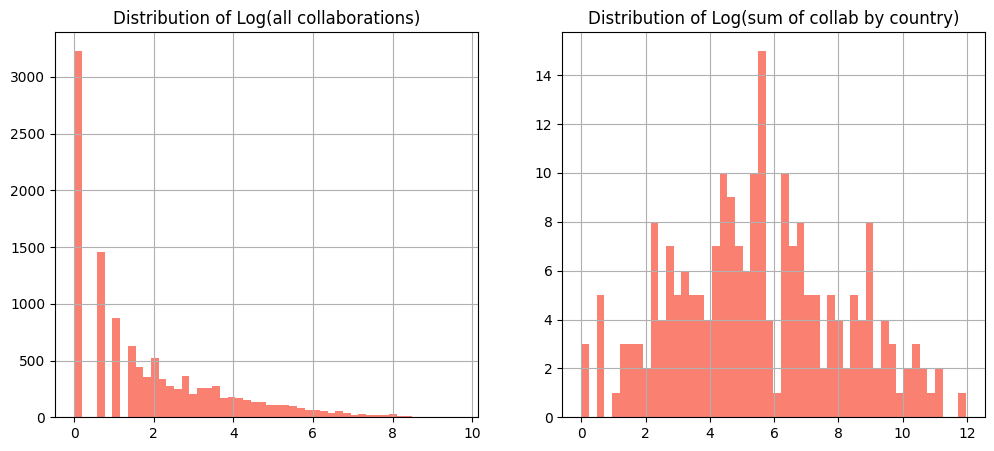

In [134]:
# Example data
data = df_collaboration_stats.log_total_collaborations.dropna().values

# KS test against standard normal
stat, p_value = kstest((data - data.mean()) / data.std(), 'norm')

print("For Log(Sum of collaborations by country):")
# print("KS statistic:", stat)
# print("p-value:", p_value)
if p_value > 0.05:
    print(f"Normal distribution hypothesis is accepted with p-value {p_value}")
else:
    print(f"Normal distribution hypothesis is rejected with p-value {p_value}")

plt.figure(figsize=(12, 5))
plt.subplot(121)

plt.hist(np.log(df_collaboration_non_diag[df_collaboration_non_diag > 0].values.flatten()), bins=50, color="salmon")
plt.grid()
plt.title("Distribution of Log(all collaborations)")
# plt.show()

plt.subplot(122)
plt.hist(df_collaboration_stats.log_total_collaborations, bins=50, color="salmon")
plt.grid()
plt.title("Distribution of Log(sum of collab by country)")

plt.show()

In [170]:
# plt.plot(df_collaboration_stats.total_collaborations.sort_values().cumsum(), color="salmon", linewidth=2)
# plt.title(f"Lorenz curve (sum of collaborations by country), Gini = {np.round(uf.gini(df_collaboration_stats.total_collaborations), 2)}")
# plt.xticks([])
# plt.show()

In [197]:
df_collaboration_stats.region.value_counts()

region
Africa      53
Europe      50
Asia        50
Americas    49
Oceania     16
Name: count, dtype: int64

In [155]:
df_collaboration_stats[df_collaboration_stats.region.isna()]

,total_collaborations,log_total_collaborations,self_contribution_share,name,region,sub-region
country,,,,,,
TW,8796.0,9.082052,0.900817,"Taiwan, Province of China",NaN,NaN
XK,58.0,4.060443,0.735317,NaN,NaN,NaN


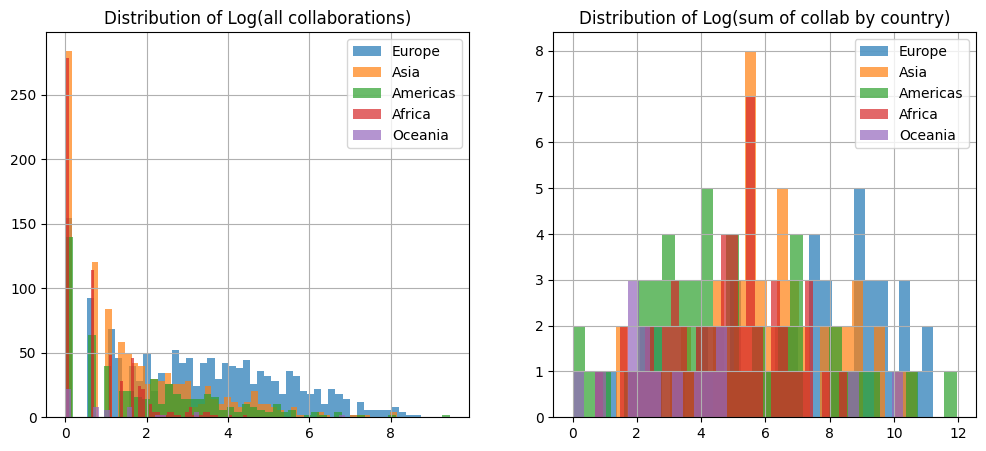

In [182]:
region_list = df_collaboration_stats.region.dropna().unique()

plt.figure(figsize=(12, 5))
for region in region_list:

    df_plot = df_collaboration_stats.query(f"region == \"{region}\"")
    plt.subplot(121)

    plt.hist(np.log(df_collaboration_non_diag.loc[df_plot.index, df_plot.index]
                    [df_collaboration_non_diag.loc[df_plot.index, df_plot.index] > 0].values.flatten()),
             bins=50, label=region, alpha=0.7)

    plt.subplot(122)
    plt.hist(df_plot.log_total_collaborations, bins=30, label=region, alpha=0.7)

plt.subplot(121)
plt.legend()
plt.grid()
plt.title(f"Distribution of Log(all collaborations)")

plt.subplot(122)
plt.legend()
plt.grid()
plt.title(f"Distribution of Log(sum of collab by country)")

plt.show()

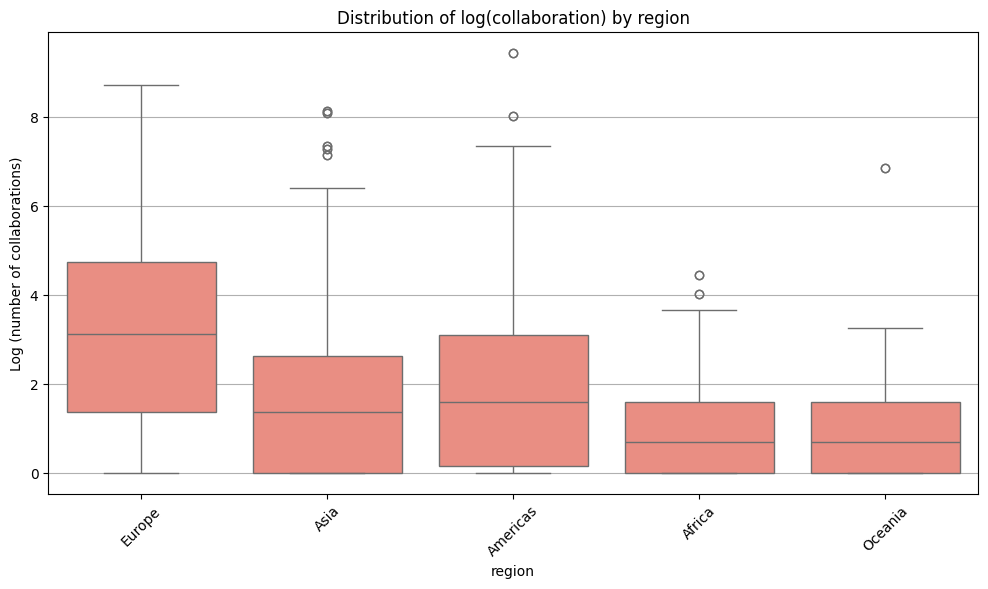

In [379]:
data = []

for region in df_collaboration_stats['region'].dropna().unique():
    subset = df_collaboration_stats.query(f"region == '{region}'").index.to_list()
    df_plot = df_collaboration.loc[subset, subset].copy()
    np.fill_diagonal(df_plot.values, 0)

    # flatten all non-zero values
    values = np.log(df_plot[df_plot > 0]).values.flatten()

    for v in values:
        data.append({"region": region, "value": v})

df_box = pd.DataFrame(data)

plt.figure(figsize=(12,6))
sns.boxplot(data=df_box, x="region", y="value", color="salmon")
plt.xticks(rotation=45)
plt.ylabel("Log (number of collaborations)")
plt.title("Distribution of log(collaboration) by region")
plt.grid(axis="y")
plt.show()

In [221]:
px.scatter(df_collaboration_stats, x="log_total_articles", y="log_total_collaborations", color="region", hover_name="name",
           title="Total articles vs Total collaborations")

# Self-Contribution Share and Collaboration Share

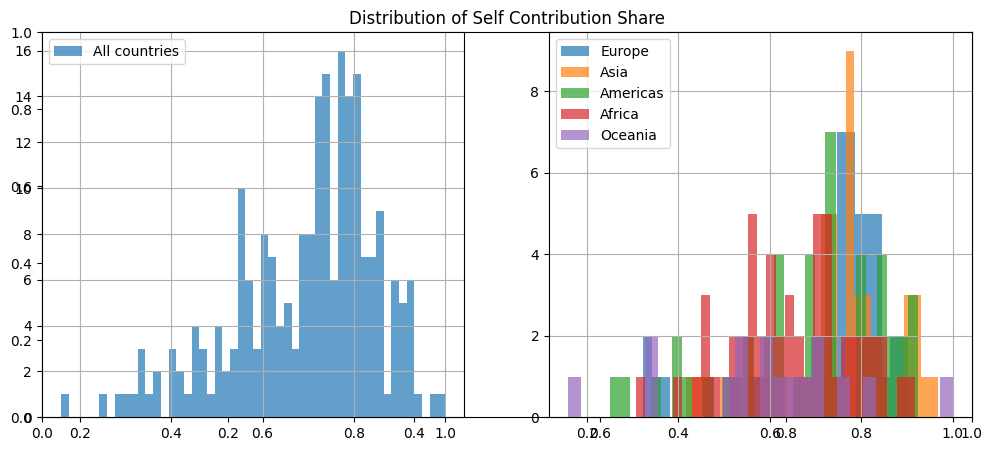

In [210]:
plt.figure(figsize=(12, 5))
plt.title(f"Distribution of Self Contribution Share")

plt.subplot(121)

plt.hist(df_collaboration_stats.self_contribution_share, bins=50, label="All countries", alpha=0.7)
plt.legend()
plt.grid()

plt.subplot(122)
region_list = df_collaboration_stats.region.dropna().unique()
# region_list = ["Americas"]
for region in region_list:

    df_plot = df_collaboration_stats.query(f"region == \"{region}\"")
    plt.hist(df_plot.self_contribution_share, bins=30, label=region, alpha=0.7)

plt.legend()
plt.grid()

plt.show()

In [227]:
px.scatter(df_collaboration_stats, x="log_total_articles", y="log_self_contribution", color="region", hover_name="name",
           title="Total articles vs Self-contribution")

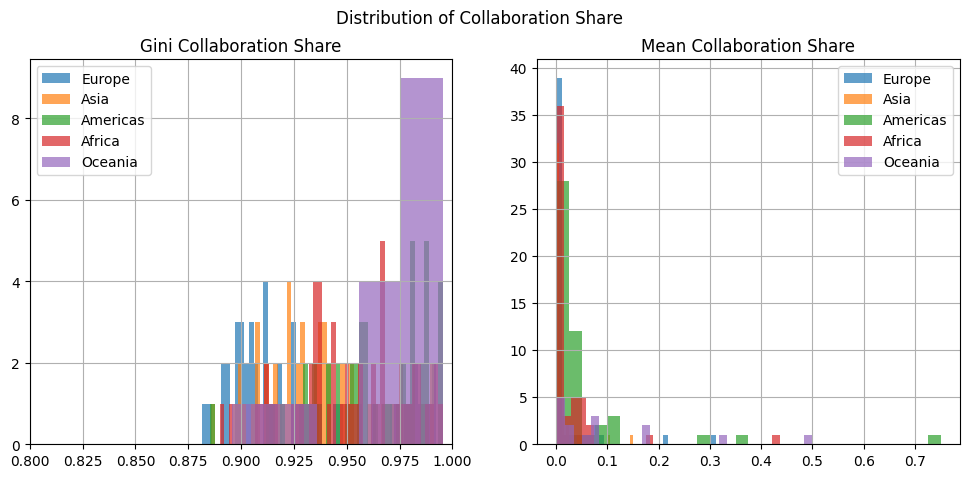

In [418]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle("Distribution of Collaboration Share")

region_list = df_collaboration_stats.region.dropna().unique()
# region_list = ["Europe", "Africa", "Americas"]

for region in region_list:
    df_plot = df_collaboration_stats.query(f"region == '{region}'")

    # draw on left axis
    ax1.hist(df_plot.gini_collaboration_share, bins=50, alpha=0.7, label=region)

    # draw on right axis
    ax2.hist(df_plot.mean_collaboration_share, bins=30, alpha=0.7, label=region)

# Add legends and gridlines
ax1.legend()
ax1.grid()
ax1.set_title("Gini Collaboration Share")
ax1.set_xlim([0.8, 1])

ax2.legend()
ax2.grid()
ax2.set_title("Mean Collaboration Share")

plt.show()

In [419]:
px.scatter(df_collaboration_stats,
           x="log_total_articles",
           y="gini_collaboration_share",
           hover_name="name",
           color="region",
)

In [163]:
# # Example data
# region = "Oceania"
# df_plot = df_collaboration_stats.query(f"region == \"{region}\"")
# # display(df_plot.head())
# data = df_plot.log_total_collaborations.dropna().values
#
# # KS test against standard normal
# stat, p_value = kstest((data - data.mean()) / data.std(), 'norm')
#
# print("For Log(Sum of collaborations by country):")
# # print("KS statistic:", stat)
# # print("p-value:", p_value)
# if p_value > 0.05:
#     print(f"Normal distribution hypothesis is accepted with p-value {p_value}")
# else:
#     print(f"Normal distribution hypothesis is rejected with p-value {p_value}")
#
# plt.figure(figsize=(12, 5))
# plt.subplot(121)
#
# plt.hist(np.log(df_collaboration_non_diag.loc[df_plot.index, df_plot.index]
#                 [df_collaboration_non_diag.loc[df_plot.index, df_plot.index] > 0].values.flatten()), bins=50, color="salmon")
# plt.grid()
# plt.title(f"Distribution of Log(all collaborations -- {region})")
# # plt.show()
#
# plt.subplot(122)
# plt.hist(df_plot.log_total_collaborations, bins=30, color="salmon")
# plt.grid()
# plt.title(f"Distribution of Log(sum of collab by country -- {region})")
#
# plt.show()

In [ ]:
# importlib.reload(uf)

# subset = uf.top_n_countries_by_articles(20)
# region="Europe"
# subset = df_collaboration_stats.query(f"region == \"{region}\"").index.to_list()
# country = "FR"
# subset = df_collaboration_weighted_norm.loc[country].sort_values(ascending=False).head(30).index.to_list()
# country = "CU"
# subset = df_collaboration_weighted_norm[country].sort_values(ascending=False).head(30).index.to_list()
subset = df_collaboration_weighted_norm.index.to_list()

uf.plotly_heatmap(
    df_collaboration_weighted_norm.T.loc[subset, subset],
    y_labels=subset,
    x_labels=subset,
    y_type="country",
    x_type="country",
    y_name="X-Country",
    x_name="Y-Country",
    title="Collaborations",
    line_height=20,
    z_min=0, z_max=1
)

In [424]:
# importlib.reload(uf)

# subset = uf.top_n_countries_by_articles(20)
# region="Europe"
# subset = df_collaboration_stats.query(f"region == \"{region}\"").index.to_list()
# country = "FR"
# subset = df_collaboration_weighted_norm.loc[country].sort_values(ascending=False).head(30).index.to_list()
# country = "CU"
# subset = df_collaboration_weighted_norm[country].sort_values(ascending=False).head(30).index.to_list()
subset = df_collaboration_weighted_norm.index.to_list()

uf.plotly_heatmap(
    df_collaboration_weighted_norm.loc[subset, subset],
    y_labels=subset,
    x_labels=subset,
    y_type="country",
    x_type="country",
    y_name="X-Country",
    x_name="Y-Country",
    title="Collaborations",
    line_height=20,
    z_min=0, z_max=1
)

In [316]:
country = "FR"
threshold = 0.05
df_test = (
    df_collaboration_weighted_norm
    .T
    .sort_values(country, ascending=False)
    .query(f"{country} > {threshold}")
    .T
)
df_test = df_test.loc[df_test.columns]
# df_test

In [317]:
A = df_test.values  # shape (n, n)

G = nx.from_numpy_array(A)
mapping = dict(enumerate(df_test.index))
G = nx.relabel_nodes(G, mapping)

In [318]:
import networkx as nx
import plotly.graph_objects as go

pos = nx.spring_layout(
    G,
    k=3,
    iterations=300,
    seed=42,
    dim=3   # 👈 THIS is the key change
)

In [319]:
edge_x = []
edge_y = []
edge_z = []

for u, v in G.edges():
    x0, y0, z0 = pos[u]
    x1, y1, z1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

edge_trace = go.Scatter3d(
    x=edge_x,
    y=edge_y,
    z=edge_z,
    mode='lines',
    line=dict(width=0.6),
    hoverinfo='none',
    opacity=0.4
)

In [320]:
color_by_region = {
    "Africa": "red",
    "Americas": "green",
    "Asia": "orange",
    "Europe": "purple",
    "Oceania": "blue"
}

In [321]:
node_x = []
node_y = []
node_z = []
node_size = []
node_color = []
node_text = []

for node in G.nodes():
    x, y, z = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_z.append(z)

    # adapt to your data
    node_size.append(5 + 30 * G.nodes[node].get("share", 0))
    node_color = [color_by_region[r] for r in df_collaboration_stats.loc[df_test.index].region.to_list()]
    node_text.append(str(node))  # country name / code

In [322]:
node_trace = go.Scatter3d(
    x=node_x,
    y=node_y,
    z=node_z,
    mode='markers',
    hoverinfo='text',
    text=node_text,
    marker=dict(
        size=node_size,
        color=node_color,
        colorscale='Viridis',
        opacity=0.9,
        showscale=True,
        line=dict(width=0.3)
    )
)

In [323]:
fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title="3D Collaboration Network",
        title_x=0.5,
        showlegend=False,
        margin=dict(l=0, r=0, t=40, b=0),
        scene=dict(
            xaxis=dict(showbackground=False, visible=False),
            yaxis=dict(showbackground=False, visible=False),
            zaxis=dict(showbackground=False, visible=False),
        )
    )
)

fig.show()

In [325]:
uf.get_country_info("PF")

,name,region,sub-region,code
78,French Polynesia,Oceania,Polynesia,PF
